# Atom-Count EGNN Split-Temperature Experiment

This is a minimal, self-contained aligned-loss experiment for one molecule size at a time. The default target is every QM9 molecule with exactly `5` atoms, not one single molecule.

The EGNN generator follows the pattern from `aligned_loss.ipynb`. The aligned drift loss uses separate temperatures:

- `posit_sigma`: position bandwidth. Start high; this notebook defaults to `3.0-6.0`.
- `types_sigma`: atom-type spherical bandwidth. Start lower; this notebook defaults to `0.25-2.0`.

The alignment uses exact atom permutations, so this notebook is intended for small atom counts. `ATOM_COUNT = 5` is safe. Going much above 7-8 atoms will become expensive.


In [23]:
from __future__ import annotations

import csv
import io
import itertools
import math
import os
import random
import sys
import time
from pathlib import Path
from typing import Any

import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.datasets import QM9
from torch_geometric.nn import MessagePassing
from IPython.display import Image, display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from model.mol_utils.stability import batch_to_stability, heavy_atom_counts
from model.mol_utils.validity import batch_to_validity

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

DATA_ROOT = REPO_ROOT / "data" / "QM9"
RESULTS_DIR = REPO_ROOT / "notebooks" / "aligned_temperature_atom_count_egnn_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MPLCONFIG_DIR = RESULTS_DIR / "mplconfig"
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIG_DIR))

import matplotlib.pyplot as plt


def _show_figure(fig, *, dpi: int = 150) -> None:
    fig.tight_layout()
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight", dpi=dpi)
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

print(f"device={DEVICE}")
print(f"results_dir={RESULTS_DIR}")


device=mps
results_dir=/Users/olivierstam/Library/CloudStorage/OneDrive-Personal/Universiteit/Msc AI/Deep Learning 2/drifting-experiments/notebooks/aligned_temperature_atom_count_egnn_results


## Parameters to tweak

The main experiment target is `ATOM_COUNT`, and the main scientific knobs are `POSIT_SIGMAS` and `TYPES_SIGMAS`.

- `ATOM_COUNT`: train against all real QM9 molecules with this atom count. Default: `5`.
- `POSIT_SIGMAS`: position temperatures. You wanted these higher, so default is `3, 4, 5, 6`.
- `TYPES_SIGMAS`: atom-type temperatures. Keep these lower initially.
- `POSIT_ETA`, `TYPES_ETA`: drift step sizes. Lower these if gradients spike or molecules explode.
- `SCALE_LOSS`: weight on the type part of the final target-matching loss. Raise if atom types lag geometry.
- `N_GEN`: generated molecules per training step. Larger gives a better generated-vs-generated repulsion estimate but costs more.
- `N_EVAL`: generated molecules used after training for validity/uniqueness/stability and best-match visualization.
- `NUM_ITERS`: use a small value for sweeps, then rerun promising pairs longer.
- `NUM_BLOCKS`: the EGNN depth. More blocks means more coordinate refinement steps.
- `NUM_LAYERS_PER_BLOCK`: extra type-message-passing layers inside each block before a coordinate update.


In [24]:
ATOM_COUNT = 5
MAX_REAL_MOLS = None  # None means use every QM9 molecule with ATOM_COUNT atoms.

POSIT_SIGMA = 4.0
TYPES_SIGMA = 0.5

POSIT_SIGMAS = [3.0, 4.0, 5.0, 6.0]
TYPES_SIGMAS = [0.25, 0.5, 1.0, 2.0]
SEEDS = [0]

N_GEN = 32
N_EVAL = 256
NUM_ITERS = 1000
LR = 1e-4
POSIT_ETA = 0.5
TYPES_ETA = 0.7
SCALE_LOSS = 1.0
GRAD_CLIP = 1.0
LOG_EVERY = 100
ALIGN_MAX_ITER = 5

NUM_ATOM_TYPES = 5
NUM_BLOCKS = 5
HIDDEN_NF = 256
NUM_LAYERS_PER_BLOCK = 1
ATTENTION = True
TANH_COORD_UPDATES = False
COORDS_RANGE = 15.0
AGGR_TYPE = "sum"


## Molecule, evaluation, and geometry utilities


In [25]:
ATOM_NAMES = ["H", "C", "N", "O", "F"]
ATOM_COLORS = ["lightgray", "dimgray", "steelblue", "tomato", "limegreen"]
Z_TO_INDEX = {1: 0, 6: 1, 7: 2, 8: 3, 9: 4}
_PERM_CACHE: dict[tuple[int, str], torch.Tensor] = {}


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def center_positions(pos: torch.Tensor) -> torch.Tensor:
    return pos - pos.mean(dim=-2, keepdim=True)


def sphere_normalize(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    return x / x.norm(dim=-1, keepdim=True).clamp_min(eps)


def probs_to_sphere(p: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    p = p.clamp_min(eps)
    p = p / p.sum(dim=-1, keepdim=True).clamp_min(eps)
    return sphere_normalize(torch.sqrt(p), eps)


def sphere_project_tangent(x: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
    return v - (x * v).sum(dim=-1, keepdim=True) * x


def sphere_exp(x: torch.Tensor, v: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    x = sphere_normalize(x, eps)
    v = sphere_project_tangent(x, v)
    v_norm = v.norm(dim=-1, keepdim=True)
    direction = v / v_norm.clamp_min(eps)
    out = torch.cos(v_norm) * x + torch.sin(v_norm) * direction
    approx = sphere_normalize(x + v, eps)
    out = torch.where(v_norm < 1e-5, approx, out)
    return sphere_normalize(out, eps)


def geodesic_distance(x: torch.Tensor, y: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    x = sphere_normalize(x, eps)
    y = sphere_normalize(y, eps)
    dot = (x * y).sum(dim=-1).clamp(-1.0 + 1e-7, 1.0 - 1e-7)
    return torch.acos(dot)


def make_batch_vec(n_molecules: int, n_atoms: int, device: torch.device | None = None) -> torch.Tensor:
    return torch.arange(n_molecules, device=device).repeat_interleave(n_atoms)


def make_dense_edge_index(n_atoms: int, device: torch.device) -> torch.Tensor:
    idx = torch.arange(n_atoms, device=device)
    src, dst = torch.meshgrid(idx, idx, indexing="ij")
    mask = src != dst
    return torch.stack([src[mask], dst[mask]], dim=0)


def make_batched_dense_edge_index(n_molecules: int, n_atoms: int, device: torch.device) -> torch.Tensor:
    base = make_dense_edge_index(n_atoms, device)
    offsets = torch.arange(n_molecules, device=device).view(-1, 1, 1) * n_atoms
    return (base.unsqueeze(0) + offsets).permute(1, 0, 2).reshape(2, -1)


def one_hot_atom_types(data: Any) -> torch.Tensor:
    real_atom_types = getattr(data, "real_atom_types", None)
    if real_atom_types is not None:
        return real_atom_types.float()
    indices = torch.tensor([Z_TO_INDEX[int(z.item())] for z in data.z], dtype=torch.long)
    return F.one_hot(indices, num_classes=NUM_ATOM_TYPES).float()


def load_atom_count_cohort(
    dataset: QM9,
    atom_count: int,
    max_mols: int | None = None,
    device: torch.device | str | None = None,
):
    indices = [i for i in range(len(dataset)) if int(dataset[i].num_nodes) == atom_count]
    if max_mols is not None:
        indices = indices[:max_mols]
    if not indices:
        raise ValueError(f"No QM9 molecules found with exactly {atom_count} atoms.")
    if atom_count > 8:
        raise ValueError("Exact factorial assignment is expensive above roughly 8 atoms.")

    pos, types = [], []
    for idx in indices:
        data = dataset[idx]
        pos.append(center_positions(data.pos.float()))
        types.append(one_hot_atom_types(data))
    pos_t = torch.stack(pos, dim=0)
    types_t = torch.stack(types, dim=0)
    if device is not None:
        pos_t = pos_t.to(device)
        types_t = types_t.to(device)
    return pos_t, types_t, indices


def evaluate_generated_molecules(gen_pos: torch.Tensor, gen_type_probs: torch.Tensor) -> dict[str, float]:
    if gen_type_probs.dim() == 3:
        hard_types = gen_type_probs.argmax(dim=-1).long()
    else:
        hard_types = gen_type_probs.long()

    n_mol, n_atoms = gen_pos.shape[:2]
    pos_flat = gen_pos.detach().cpu().reshape(n_mol * n_atoms, 3)
    types_flat = hard_types.detach().cpu().reshape(n_mol * n_atoms)
    batch_vec = make_batch_vec(n_mol, n_atoms).cpu()

    results = batch_to_validity(pos_flat, types_flat, batch_vec)
    heavy = heavy_atom_counts(types_flat, batch_vec)
    atom_stable_frac, mol_stable_frac = batch_to_stability(pos_flat, types_flat, batch_vec)

    n_total = len(results)
    n_valid = sum(1 for ok, _ in results if ok)
    valid_ids = [ident for ok, ident in results if ok and ident is not None]

    return {
        "validity": n_valid / n_total if n_total else 0.0,
        "uniqueness": len(set(valid_ids)) / len(valid_ids) if valid_ids else 0.0,
        "heavy_atom_mean": float(np.mean(heavy)) if heavy else 0.0,
        "atom_stability": float(atom_stable_frac),
        "mol_stability": float(mol_stable_frac),
    }


## EGNN copied from `aligned_loss.ipynb`


In [26]:
class TypeGCN(MessagePassing):
    propagate_type = {"type_feat": torch.Tensor, "edge_attr": torch.Tensor}

    def __init__(self, hidden_nf: int, attention: bool = True, aggr_type: str = "sum"):
        super().__init__(aggr=aggr_type)
        in_message_dim = hidden_nf * 2 + 2
        self.message_mlp = nn.Sequential(
            nn.Linear(in_message_dim, in_message_dim),
            nn.SiLU(),
            nn.Linear(in_message_dim, hidden_nf),
        )
        self.update_mlp = nn.Sequential(
            nn.Linear(hidden_nf * 2, hidden_nf),
            nn.SiLU(),
            nn.Linear(hidden_nf, hidden_nf),
        )
        self.attention = attention
        if self.attention:
            self.att_mlp = nn.Sequential(nn.Linear(hidden_nf, 1), nn.Sigmoid())

    def message(self, type_feat_i: torch.Tensor, type_feat_j: torch.Tensor, edge_attr: torch.Tensor) -> torch.Tensor:
        out = self.message_mlp(torch.cat([type_feat_i, type_feat_j, edge_attr], dim=-1))
        if self.attention:
            out = out * self.att_mlp(out)
        return out

    def update(self, aggr_out: torch.Tensor, type_feat: torch.Tensor) -> torch.Tensor:
        return type_feat + self.update_mlp(torch.cat([aggr_out, type_feat], dim=-1))

    def forward(self, type_feat: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor) -> torch.Tensor:
        return self.propagate(edge_index, type_feat=type_feat, edge_attr=edge_attr)


class PosGCN(MessagePassing):
    propagate_type = {
        "type_feat": torch.Tensor,
        "scaled_dir_vector": torch.Tensor,
        "edge_attr": torch.Tensor,
    }

    def __init__(
        self,
        hidden_nf: int,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__(aggr=aggr_type)
        in_message_dim = hidden_nf * 2 + 2
        layer = nn.Linear(hidden_nf, 1, bias=False)
        torch.nn.init.xavier_uniform_(layer.weight, gain=0.001)
        self.coord_mlp = nn.Sequential(
            nn.Linear(in_message_dim, hidden_nf),
            nn.SiLU(),
            nn.Linear(hidden_nf, hidden_nf),
            nn.SiLU(),
            layer,
        )
        self.tanh_coord_updates = tanh_coord_updates
        self.coords_range = coords_range

    def message(
        self,
        type_feat_i: torch.Tensor,
        type_feat_j: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> torch.Tensor:
        weight = self.coord_mlp(torch.cat([type_feat_i, type_feat_j, edge_attr], dim=-1))
        if self.tanh_coord_updates:
            weight = torch.tanh(weight) * self.coords_range
        return scaled_dir_vector * weight

    def forward(
        self,
        pos: torch.Tensor,
        type_feat: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> torch.Tensor:
        delta = self.propagate(
            edge_index,
            type_feat=type_feat,
            edge_attr=edge_attr,
            scaled_dir_vector=scaled_dir_vector,
        )
        return pos + delta


class EquivariantBlock(nn.Module):
    def __init__(
        self,
        hidden_nf: int,
        n_layers: int = 1,
        attention: bool = True,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__()
        self.type_update = nn.ModuleList(
            [TypeGCN(hidden_nf, attention=attention, aggr_type=aggr_type) for _ in range(n_layers)]
        )
        self.coord_update = PosGCN(
            hidden_nf,
            tanh_coord_updates=tanh_coord_updates,
            coords_range=coords_range,
            aggr_type=aggr_type,
        )

    def forward(
        self,
        type_feat: torch.Tensor,
        pos: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        for type_gcn in self.type_update:
            type_feat = type_gcn(type_feat=type_feat, edge_index=edge_index, edge_attr=edge_attr)
        pos = self.coord_update(
            pos=pos,
            type_feat=type_feat,
            edge_index=edge_index,
            edge_attr=edge_attr,
            scaled_dir_vector=scaled_dir_vector,
        )
        return type_feat, pos


def compute_edge_properties(
    pos: torch.Tensor,
    edge_index: torch.Tensor,
    norm_constant: float = 1.0,
) -> tuple[torch.Tensor, torch.Tensor]:
    src, dst = edge_index
    dist = pos[src] - pos[dst]
    squared_norm = dist.pow(2).sum(dim=-1)
    norm = squared_norm.sqrt()
    scaled_dir_vector = dist / (norm.unsqueeze(-1) + norm_constant)
    return squared_norm, scaled_dir_vector


class EGNN(nn.Module):
    def __init__(
        self,
        num_atom_types: int,
        num_blocks: int = 9,
        hidden_nf: int = 256,
        num_layers_per_block: int = 1,
        attention: bool = True,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__()
        self.type_embedding = nn.Linear(num_atom_types, hidden_nf)
        self.type_embedding_out = nn.Linear(hidden_nf, num_atom_types)
        self.blocks = nn.ModuleList(
            [
                EquivariantBlock(
                    hidden_nf,
                    n_layers=num_layers_per_block,
                    attention=attention,
                    tanh_coord_updates=tanh_coord_updates,
                    coords_range=coords_range,
                    aggr_type=aggr_type,
                )
                for _ in range(num_blocks)
            ]
        )

    def forward(
        self,
        pos_noise: torch.Tensor,
        type_noise: torch.Tensor,
        edge_index: torch.Tensor,
        return_change_in_pos: bool = False,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        gen_feats = self.type_embedding(type_noise)
        gen_pos = pos_noise
        initial_squared_norm, _ = compute_edge_properties(gen_pos, edge_index)
        pos_list = []
        if return_change_in_pos:
            pos_list.append(gen_pos.clone())
        for block in self.blocks:
            squared_norm, scaled_dir_vector = compute_edge_properties(gen_pos, edge_index)
            edge_attr = torch.cat(
                [initial_squared_norm.unsqueeze(-1), squared_norm.unsqueeze(-1)],
                dim=-1,
            )
            gen_feats, gen_pos = block(
                type_feat=gen_feats,
                pos=gen_pos,
                edge_index=edge_index,
                scaled_dir_vector=scaled_dir_vector,
                edge_attr=edge_attr,
            )
            if return_change_in_pos:
                pos_list.append(gen_pos.clone())
        gen_types = self.type_embedding_out(gen_feats)
        if return_change_in_pos:
            return gen_pos, gen_types, pos_list
        return gen_pos, gen_types


## EGNN sampling


In [27]:
def sample_egnn_noise(n_samples: int, n_atoms: int, device: torch.device) -> tuple[torch.Tensor, torch.Tensor]:
    pos_noise = torch.randn((n_samples, n_atoms, 3), device=device)
    pos_noise = center_positions(pos_noise)
    type_noise = torch.randn((n_samples, n_atoms, NUM_ATOM_TYPES), device=device)
    return pos_noise, type_noise


def generate_egnn_samples(
    model: EGNN,
    n_samples: int,
    n_atoms: int,
    device: torch.device,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    pos_noise, type_noise = sample_egnn_noise(n_samples, n_atoms, device)
    edge_index = make_batched_dense_edge_index(n_samples, n_atoms, device)
    gen_pos, gen_logits = model(
        pos_noise.reshape(n_samples * n_atoms, 3),
        type_noise.reshape(n_samples * n_atoms, NUM_ATOM_TYPES),
        edge_index,
    )
    gen_pos = center_positions(gen_pos.reshape(n_samples, n_atoms, 3))
    gen_logits = gen_logits.reshape(n_samples, n_atoms, NUM_ATOM_TYPES)
    gen_probs = F.softmax(gen_logits, dim=-1)
    gen_sphere = probs_to_sphere(gen_probs)
    return gen_pos, gen_probs, gen_sphere


## Alignment and split-temperature drift loss


In [28]:
def _permutations(n_atoms: int, device: torch.device) -> torch.Tensor:
    key = (n_atoms, str(device))
    cached = _PERM_CACHE.get(key)
    if cached is None:
        cached = torch.tensor(
            list(itertools.permutations(range(n_atoms))),
            dtype=torch.long,
            device=device,
        )
        _PERM_CACHE[key] = cached
    return cached


@torch.no_grad()
def _kabsch_rotations(gen_pos: torch.Tensor, real_pos: torch.Tensor) -> torch.Tensor:
    if real_pos.ndim != 3:
        raise ValueError(f"real_pos must be [N_real, N_atoms, 3], got {real_pos.shape}")
    if gen_pos.ndim == 3:
        gen_c = center_positions(gen_pos)
        real_c = center_positions(real_pos)
        H = torch.einsum("gni,rnj->grij", gen_c, real_c)
    elif gen_pos.ndim == 4:
        gen_c = center_positions(gen_pos)
        real_c = center_positions(real_pos)
        H = torch.einsum("grni,rnj->grij", gen_c, real_c)
    else:
        raise ValueError(f"gen_pos must be 3D or 4D, got {gen_pos.shape}")
    H_flat = H.reshape(-1, 3, 3)
    U, _, Vh = torch.linalg.svd(H_flat)
    V = Vh.transpose(-2, -1)
    Ut = U.transpose(-2, -1)
    R = V @ Ut
    det = torch.det(R)
    mask = det < 0
    if mask.any():
        V = V.clone()
        V[mask, :, -1] *= -1
        R = V @ Ut
    return R.reshape(H.shape[0], H.shape[1], 3, 3)


def _build_cost_matrix(
    gen_types: torch.Tensor,
    real_types: torch.Tensor,
    gen_pos: torch.Tensor,
    real_pos: torch.Tensor,
    eps: float,
    type_weight: float = 1.0,
    pos_weight: float = 0.0,
) -> torch.Tensor:
    gen_types = sphere_normalize(gen_types, eps)
    real_types = sphere_normalize(real_types, eps)
    if gen_types.ndim == 3:
        gen_types_exp = gen_types[:, None, None, :, :]
        gen_pos_exp = gen_pos[:, None, None, :, :]
    elif gen_types.ndim == 4:
        gen_types_exp = gen_types[:, :, None, :, :]
        gen_pos_exp = gen_pos[:, :, None, :, :]
    else:
        raise ValueError(f"Expected gen_types 3D or 4D, got {gen_types.shape}")
    real_types_exp = real_types[None, :, :, None, :]
    real_pos_exp = real_pos[None, :, :, None, :]
    dot = (gen_types_exp * real_types_exp).sum(dim=-1).clamp(-1.0 + 1e-7, 1.0 - 1e-7)
    type_cost = torch.acos(dot).pow(2)
    pos_cost = (gen_pos_exp - real_pos_exp).pow(2).sum(dim=-1)
    return type_weight * type_cost + pos_weight * pos_cost


@torch.no_grad()
def _exact_assignment_batched(
    gen_types: torch.Tensor,
    real_types: torch.Tensor,
    gen_pos: torch.Tensor,
    real_pos: torch.Tensor,
    eps: float,
    type_weight: float = 1.0,
    pos_weight: float = 0.0,
    chunk_pairs: int = 256,
) -> torch.Tensor:
    cost_matrix = _build_cost_matrix(gen_types, real_types, gen_pos, real_pos, eps, type_weight, pos_weight)
    n_gen, n_real, n_atoms, _ = cost_matrix.shape
    perms = _permutations(n_atoms, cost_matrix.device)
    row_idx = torch.arange(n_atoms, device=cost_matrix.device)
    flat_cost = cost_matrix.reshape(n_gen * n_real, n_atoms, n_atoms)
    best_chunks = []
    for start in range(0, flat_cost.shape[0], chunk_pairs):
        chunk = flat_cost[start : start + chunk_pairs]
        expanded = chunk[:, None, :, :].expand(-1, perms.shape[0], -1, -1)
        col_idx = perms[None, :, :, None].expand(chunk.shape[0], -1, -1, 1)
        selected = expanded.gather(dim=3, index=col_idx).squeeze(-1)
        costs = selected[:, :, row_idx].sum(dim=-1)
        best_chunks.append(perms[costs.argmin(dim=1)])
    return torch.cat(best_chunks, dim=0).reshape(n_gen, n_real, n_atoms)


def _to_pairwise(gen: torch.Tensor, n_real: int) -> torch.Tensor:
    if gen.ndim == 3:
        return gen[:, None, :, :].expand(-1, n_real, -1, -1)
    if gen.ndim == 4:
        return gen
    raise ValueError(f"Expected 3D or 4D tensor, got {gen.shape}")


def _pairwise_position_rmse(gen_pos_pairwise: torch.Tensor, real_pos: torch.Tensor) -> torch.Tensor:
    diff = gen_pos_pairwise - real_pos[None, :, :, :]
    return diff.pow(2).sum(dim=-1).mean(dim=-1).sqrt()


def permute_generated_to_real_order(gen: torch.Tensor, assignment: torch.Tensor) -> torch.Tensor:
    if gen.ndim == 3:
        gen_pairwise = gen[:, None, :, :].expand(-1, assignment.shape[1], -1, -1)
    elif gen.ndim == 4:
        gen_pairwise = gen
    else:
        raise ValueError(f"Expected gen to be 3D or 4D, got {gen.shape}")
    idx = assignment[..., None].expand(-1, -1, -1, gen.shape[-1])
    return gen_pairwise.gather(dim=2, index=idx)


def apply_pairwise_rotation(gen_pos: torch.Tensor, R: torch.Tensor) -> torch.Tensor:
    if gen_pos.ndim == 3:
        gen_pairwise = gen_pos[:, None, :, :].expand(-1, R.shape[1], -1, -1)
    elif gen_pos.ndim == 4:
        gen_pairwise = gen_pos
    else:
        raise ValueError(f"gen_pos must be 3D or 4D, got {gen_pos.shape}")
    return gen_pairwise @ R


def unpermute_real_order_to_gen_order(x_perm: torch.Tensor, assignment: torch.Tensor) -> torch.Tensor:
    x = torch.empty_like(x_perm)
    idx = assignment[..., None].expand_as(x_perm)
    x.scatter_(dim=2, index=idx, src=x_perm)
    return x


def find_rotation_and_permutation(
    gen_pos: torch.Tensor,
    real_pos: torch.Tensor,
    gen_types: torch.Tensor,
    real_types: torch.Tensor,
    eps: float,
    max_iter: int = 5,
    pos_tol: float = 1e-4,
    min_iter: int = 1,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    g_types = gen_types.clone().detach()
    g_pos = gen_pos.clone().detach()
    n_gen, n_real, n_atoms = gen_pos.shape[0], real_pos.shape[0], gen_pos.shape[1]
    active = torch.ones(n_gen, n_real, device=gen_pos.device, dtype=torch.bool)
    total_assignment = torch.arange(n_atoms, device=gen_pos.device).view(1, 1, n_atoms)
    total_assignment = total_assignment.expand(n_gen, n_real, n_atoms).clone()
    total_R = torch.eye(3, device=gen_pos.device, dtype=gen_pos.dtype).view(1, 1, 3, 3)
    total_R = total_R.expand(n_gen, n_real, 3, 3).clone()

    for step in range(max_iter):
        pos_weight = 0.0 if step == 0 else 0.1
        old_g_pos = _to_pairwise(g_pos, n_real)
        old_g_types = _to_pairwise(g_types, n_real)
        step_assignment = _exact_assignment_batched(
            g_types,
            real_types,
            g_pos,
            real_pos,
            eps=eps,
            type_weight=1.0,
            pos_weight=pos_weight,
        )
        cand_g_pos = permute_generated_to_real_order(g_pos, step_assignment)
        cand_g_types = permute_generated_to_real_order(g_types, step_assignment)
        step_R = _kabsch_rotations(cand_g_pos, real_pos)
        cand_g_pos = apply_pairwise_rotation(cand_g_pos, step_R)
        cand_total_assignment = total_assignment.gather(dim=2, index=step_assignment)
        cand_total_R = total_R @ step_R
        pair_mask = active[..., None, None]
        assign_mask = active[..., None]
        g_pos = torch.where(pair_mask, cand_g_pos, old_g_pos)
        g_types = torch.where(pair_mask, cand_g_types, old_g_types)
        total_assignment = torch.where(assign_mask, cand_total_assignment, total_assignment)
        total_R = torch.where(pair_mask, cand_total_R, total_R)
        done = _pairwise_position_rmse(g_pos, real_pos) <= pos_tol
        active = torch.ones_like(done) if step + 1 < min_iter else ~done
        if not active.any():
            break
    return total_assignment, total_R, g_pos, g_types


def _pairwise_geodesic_distance_and_log(
    x: torch.Tensor,
    y: torch.Tensor,
    manifold: str = "euclidean",
    eps: float = 1e-8,
) -> tuple[torch.Tensor, torch.Tensor]:
    if manifold == "euclidean":
        diff = x - y[None, :, :, :]
        sq_distances = diff.pow(2).sum(dim=-1).sum(dim=-1)
    elif manifold == "spherical":
        x = sphere_normalize(x, eps)
        y = sphere_normalize(y.unsqueeze(0), eps)
        dot = (x * y).sum(dim=-1).clamp(-1.0 + 1e-7, 1.0 - 1e-7)
        theta = torch.acos(dot)
        sq_distances = theta.pow(2).sum(dim=-1).clamp_min(eps)
        u = y - dot.unsqueeze(-1) * x
        u_norm = u.norm(dim=-1, keepdim=True)
        out = theta.unsqueeze(-1) / u_norm.clamp_min(eps) * u
        first_order = sphere_project_tangent(x, y - x)
        out = torch.where(theta.unsqueeze(-1) < 1e-5, first_order, out)
        diff = sphere_project_tangent(x, out)
    else:
        raise ValueError(f"Undefined manifold: {manifold}")
    return sq_distances, diff


def _kernel_stats(kernel: torch.Tensor, eps: float) -> dict[str, torch.Tensor]:
    weights = kernel / kernel.sum(dim=1, keepdim=True).clamp_min(eps)
    entropy = -(weights * (weights + eps).log()).sum(dim=1)
    return {
        "entropy": entropy.mean().detach(),
        "effective_neighbors": entropy.exp().mean().detach(),
        "max_weight": weights.max(dim=1).values.mean().detach(),
    }


def _calc_drift_direction(
    dist: torch.Tensor,
    diff: torch.Tensor,
    permutation: torch.Tensor,
    R: torch.Tensor,
    sigma: float,
    eps: float = 1e-8,
    euclidean: bool = True,
) -> tuple[torch.Tensor, dict[str, torch.Tensor]]:
    kernel = torch.exp(-dist / (2 * sigma**2))
    grad_kernel = diff * kernel.unsqueeze(-1).unsqueeze(-1) / (sigma**2)
    if euclidean:
        grad_kernel = -grad_kernel
        grad_kernel = grad_kernel @ R.transpose(-2, -1)
    grad_kernel = unpermute_real_order_to_gen_order(grad_kernel, permutation)
    drift = grad_kernel.sum(dim=1) / kernel.sum(dim=1).clamp_min(eps).unsqueeze(-1).unsqueeze(-1)
    return drift, _kernel_stats(kernel, eps)


def compute_aligning_drift_loss(
    gen_pos: torch.Tensor,
    real_pos: torch.Tensor,
    gen_types_sphere: torch.Tensor,
    real_types: torch.Tensor,
    posit_sigma: float = 4.0,
    types_sigma: float = 0.5,
    posit_eta: float = 0.5,
    types_eta: float = 0.7,
    eps: float = 1e-8,
    scale_loss: float = 1.0,
    align_max_iter: int = 5,
) -> tuple[torch.Tensor, dict[str, torch.Tensor]]:
    real_types = real_types.float()
    n_gen = gen_pos.shape[0]
    permutation_pos, R_pos, _, _ = find_rotation_and_permutation(
        gen_pos, real_pos, gen_types_sphere, real_types, eps=eps, max_iter=align_max_iter
    )
    permutation_neg, R_neg, _, _ = find_rotation_and_permutation(
        gen_pos, gen_pos, gen_types_sphere, gen_types_sphere, eps=eps, max_iter=align_max_iter
    )
    aligned_pos_pos = permute_generated_to_real_order(gen_pos, permutation_pos)
    aligned_types_pos = permute_generated_to_real_order(gen_types_sphere, permutation_pos)
    aligned_pos_neg = permute_generated_to_real_order(gen_pos, permutation_neg)
    aligned_types_neg = permute_generated_to_real_order(gen_types_sphere, permutation_neg)
    aligned_pos_pos = apply_pairwise_rotation(aligned_pos_pos, R_pos)
    aligned_pos_neg = apply_pairwise_rotation(aligned_pos_neg, R_neg)
    posit_dist_pos, posit_diff_pos = _pairwise_geodesic_distance_and_log(aligned_pos_pos, real_pos, "euclidean", eps)
    posit_dist_neg, posit_diff_neg = _pairwise_geodesic_distance_and_log(aligned_pos_neg, gen_pos.detach(), "euclidean", eps)
    types_dist_pos, types_diff_pos = _pairwise_geodesic_distance_and_log(aligned_types_pos, real_types, "spherical", eps)
    types_dist_neg, types_diff_neg = _pairwise_geodesic_distance_and_log(aligned_types_neg, gen_types_sphere.detach(), "spherical", eps)
    eye = torch.eye(n_gen, device=gen_pos.device, dtype=torch.bool)
    posit_dist_neg = posit_dist_neg.masked_fill(eye, 1e6)
    types_dist_neg = types_dist_neg.masked_fill(eye, 1e6)
    v_pos_pos, pos_kernel_stats = _calc_drift_direction(posit_dist_pos, posit_diff_pos, permutation_pos, R_pos, sigma=posit_sigma, eps=eps)
    v_pos_neg, _ = _calc_drift_direction(posit_dist_neg, posit_diff_neg, permutation_neg, R_neg, sigma=posit_sigma, eps=eps)
    v_types_pos, type_kernel_stats = _calc_drift_direction(types_dist_pos, types_diff_pos, permutation_pos, R_pos, sigma=types_sigma, eps=eps, euclidean=False)
    v_types_neg, _ = _calc_drift_direction(types_dist_neg, types_diff_neg, permutation_neg, R_neg, sigma=types_sigma, eps=eps, euclidean=False)
    v_pos = posit_eta * (v_pos_pos - v_pos_neg)
    v_types = types_eta * sphere_project_tangent(gen_types_sphere, v_types_pos - v_types_neg)
    target_pos = (gen_pos + v_pos).detach()
    target_types = sphere_exp(gen_types_sphere, v_types, eps).detach()
    molecule_position_dist = (gen_pos - target_pos).pow(2).sum(dim=-1).sum(dim=-1)
    molecule_types_dist = geodesic_distance(gen_types_sphere, target_types, eps).pow(2).sum(dim=-1)
    loss = (molecule_position_dist + scale_loss * molecule_types_dist).mean()
    stats = {
        "position_dist": molecule_position_dist.mean().detach(),
        "type_dist": molecule_types_dist.mean().detach(),
        "drift_pos_norm": v_pos.norm(dim=-1).mean().detach(),
        "drift_type_norm": v_types.norm(dim=-1).mean().detach(),
        "pos_kernel_entropy": pos_kernel_stats["entropy"],
        "type_kernel_entropy": type_kernel_stats["entropy"],
        "pos_effective_neighbors": pos_kernel_stats["effective_neighbors"],
        "type_effective_neighbors": type_kernel_stats["effective_neighbors"],
        "pos_kernel_max_weight": pos_kernel_stats["max_weight"],
        "type_kernel_max_weight": type_kernel_stats["max_weight"],
    }
    return loss, stats


## Best generated-to-real match

After training, this selects the generated molecule that best matches any real molecule in the selected atom-count cohort after permutation and rotation. This is used for the side-by-side visualization.


In [29]:
@torch.no_grad()
def select_best_generated_match(
    gen_pos: torch.Tensor,
    gen_type_probs: torch.Tensor,
    real_pos: torch.Tensor,
    real_types: torch.Tensor,
    align_max_iter: int = 5,
    eps: float = 1e-8,
):
    device = gen_pos.device
    gen_sphere = probs_to_sphere(gen_type_probs)
    permutation, R, _, _ = find_rotation_and_permutation(
        gen_pos,
        real_pos.to(device),
        gen_sphere,
        real_types.to(device),
        eps=eps,
        max_iter=align_max_iter,
    )
    aligned_pos = apply_pairwise_rotation(permute_generated_to_real_order(gen_pos, permutation), R)
    aligned_types = permute_generated_to_real_order(gen_sphere, permutation)
    real_pos_d = real_pos.to(device)
    real_types_d = real_types.to(device)

    pos_rmse = (aligned_pos - real_pos_d[None, :, :, :]).pow(2).sum(dim=-1).mean(dim=-1).sqrt()
    type_rmse = geodesic_distance(aligned_types, real_types_d[None, :, :, :], eps=eps).pow(2).mean(dim=-1).sqrt()
    score = pos_rmse + type_rmse
    flat_idx = int(score.argmin().detach().cpu().item())
    gen_idx = flat_idx // score.shape[1]
    real_idx = flat_idx % score.shape[1]

    return {
        "gen_index": int(gen_idx),
        "real_local_index": int(real_idx),
        "score": float(score[gen_idx, real_idx].detach().cpu().item()),
        "pos_rmse": float(pos_rmse[gen_idx, real_idx].detach().cpu().item()),
        "type_rmse": float(type_rmse[gen_idx, real_idx].detach().cpu().item()),
        "gen_pos_raw": gen_pos[gen_idx].detach().cpu(),
        "gen_type_probs_raw": gen_type_probs[gen_idx].detach().cpu(),
        "gen_pos_aligned": aligned_pos[gen_idx, real_idx].detach().cpu(),
        "gen_types_aligned": aligned_types[gen_idx, real_idx].detach().cpu(),
        "real_pos": real_pos[real_idx].detach().cpu(),
        "real_types": real_types[real_idx].detach().cpu(),
    }


## Single-run and grid runners


In [30]:
def _float_key(x: float) -> str:
    return str(float(x)).replace(".", "p")


def run_single_egnn_temperature(
    *,
    atom_count: int,
    real_pos: torch.Tensor,
    real_types: torch.Tensor,
    real_indices: list[int],
    posit_sigma: float,
    types_sigma: float,
    seed: int,
    n_gen: int,
    n_eval: int,
    num_iters: int,
    lr: float,
    posit_eta: float,
    types_eta: float,
    scale_loss: float,
    device: torch.device | str,
    hidden_nf: int = 256,
    num_blocks: int = 5,
    num_layers_per_block: int = 1,
    attention: bool = True,
    tanh_coord_updates: bool = False,
    coords_range: float = 15.0,
    aggr_type: str = "sum",
    grad_clip: float | None = 1.0,
    align_max_iter: int = 5,
    log_every: int = 100,
    save_dir: str | Path | None = None,
):
    device = torch.device(device)
    set_seed(seed)
    real_pos = real_pos.to(device)
    real_types = real_types.to(device)
    n_atoms = atom_count

    model = EGNN(
        num_atom_types=NUM_ATOM_TYPES,
        num_blocks=num_blocks,
        hidden_nf=hidden_nf,
        num_layers_per_block=num_layers_per_block,
        attention=attention,
        tanh_coord_updates=tanh_coord_updates,
        coords_range=coords_range,
        aggr_type=aggr_type,
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    start_time = time.time()
    history = []
    last_loss = math.nan
    last_stats = {}
    last_grad_norm = math.nan

    for step in range(num_iters):
        optimizer.zero_grad(set_to_none=True)
        gen_pos, _, gen_sphere = generate_egnn_samples(model, n_gen, n_atoms, device)
        loss, stats = compute_aligning_drift_loss(
            gen_pos,
            real_pos,
            gen_sphere,
            real_types,
            posit_sigma=posit_sigma,
            types_sigma=types_sigma,
            posit_eta=posit_eta,
            types_eta=types_eta,
            scale_loss=scale_loss,
            align_max_iter=align_max_iter,
        )
        loss.backward()
        if grad_clip is not None:
            last_grad_norm = float(torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip).detach().cpu().item())
        optimizer.step()

        last_loss = float(loss.detach().cpu().item())
        last_stats = stats
        if step == 0 or (step + 1) % log_every == 0 or step + 1 == num_iters:
            item = {
                "step": step + 1,
                "loss": last_loss,
                "position_dist": float(stats["position_dist"].cpu().item()),
                "type_dist": float(stats["type_dist"].cpu().item()),
                "drift_pos_norm": float(stats["drift_pos_norm"].cpu().item()),
                "drift_type_norm": float(stats["drift_type_norm"].cpu().item()),
                "pos_kernel_entropy": float(stats["pos_kernel_entropy"].cpu().item()),
                "type_kernel_entropy": float(stats["type_kernel_entropy"].cpu().item()),
                "pos_effective_neighbors": float(stats["pos_effective_neighbors"].cpu().item()),
                "type_effective_neighbors": float(stats["type_effective_neighbors"].cpu().item()),
                "grad_norm": last_grad_norm,
            }
            history.append(item)
            print(
                f"step={step + 1:5d} loss={item['loss']:.4g} "
                f"pos={item['position_dist']:.4g} type={item['type_dist']:.4g} grad={last_grad_norm:.4g}"
            )

    runtime_sec = time.time() - start_time
    with torch.no_grad():
        eval_pos, eval_probs, _ = generate_egnn_samples(model, n_eval, n_atoms, device)

    chem = evaluate_generated_molecules(eval_pos, eval_probs)
    best_match = select_best_generated_match(
        eval_pos,
        eval_probs,
        real_pos,
        real_types,
        align_max_iter=align_max_iter,
    )
    best_match["real_dataset_index"] = int(real_indices[best_match["real_local_index"]])

    row = {
        "atom_count": int(atom_count),
        "n_real": int(real_pos.shape[0]),
        "posit_sigma": float(posit_sigma),
        "types_sigma": float(types_sigma),
        "seed": int(seed),
        "final_loss": float(last_loss),
        "final_position_dist": float(last_stats["position_dist"].cpu().item()),
        "final_type_dist": float(last_stats["type_dist"].cpu().item()),
        "validity": chem["validity"],
        "uniqueness": chem["uniqueness"],
        "heavy_atom_mean": chem["heavy_atom_mean"],
        "atom_stability": chem["atom_stability"],
        "mol_stability": chem["mol_stability"],
        "best_match_score": best_match["score"],
        "best_match_pos_rmse": best_match["pos_rmse"],
        "best_match_type_rmse": best_match["type_rmse"],
        "best_match_real_dataset_index": best_match["real_dataset_index"],
        "drift_pos_norm": float(last_stats["drift_pos_norm"].cpu().item()),
        "drift_type_norm": float(last_stats["drift_type_norm"].cpu().item()),
        "pos_kernel_entropy": float(last_stats["pos_kernel_entropy"].cpu().item()),
        "type_kernel_entropy": float(last_stats["type_kernel_entropy"].cpu().item()),
        "pos_effective_neighbors": float(last_stats["pos_effective_neighbors"].cpu().item()),
        "type_effective_neighbors": float(last_stats["type_effective_neighbors"].cpu().item()),
        "grad_norm": float(last_grad_norm),
        "runtime_sec": float(runtime_sec),
        "n_gen": int(n_gen),
        "n_eval": int(n_eval),
        "num_iters": int(num_iters),
        "lr": float(lr),
        "posit_eta": float(posit_eta),
        "types_eta": float(types_eta),
        "scale_loss": float(scale_loss),
        "hidden_nf": int(hidden_nf),
        "num_blocks": int(num_blocks),
        "num_layers_per_block": int(num_layers_per_block),
    }

    artifact = {
        "gen_pos": eval_pos[: min(12, n_eval)].detach().cpu(),
        "gen_type_probs": eval_probs[: min(12, n_eval)].detach().cpu(),
        "real_pos": real_pos.detach().cpu(),
        "real_types": real_types.detach().cpu(),
        "real_indices": list(real_indices),
        "best_match": best_match,
    }

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        out_path = save_dir / f"atoms{atom_count}_pos{_float_key(posit_sigma)}_type{_float_key(types_sigma)}_seed{seed}.pt"
        torch.save({"row": row, "history": history, "artifact": artifact}, out_path)
        row["artifact_path"] = str(out_path)

    return row, history, artifact


def run_temperature_pair_grid(
    *,
    atom_count: int,
    real_pos: torch.Tensor,
    real_types: torch.Tensor,
    real_indices: list[int],
    posit_sigmas: list[float],
    types_sigmas: list[float],
    seeds: list[int],
    save_dir: str | Path | None = None,
    **kwargs,
):
    rows, histories, artifacts = [], {}, {}
    for posit_sigma in posit_sigmas:
        for types_sigma in types_sigmas:
            for seed in seeds:
                print(f"\n[atoms={atom_count}] posit_sigma={posit_sigma} types_sigma={types_sigma} seed={seed}")
                row, history, artifact = run_single_egnn_temperature(
                    atom_count=atom_count,
                    real_pos=real_pos,
                    real_types=real_types,
                    real_indices=real_indices,
                    posit_sigma=posit_sigma,
                    types_sigma=types_sigma,
                    seed=seed,
                    save_dir=save_dir,
                    **kwargs,
                )
                key = (float(posit_sigma), float(types_sigma), int(seed))
                rows.append(row)
                histories[key] = history
                artifacts[key] = artifact
    return rows, histories, artifacts


def write_results_csv(rows: list[dict[str, Any]], path: str | Path) -> None:
    if not rows:
        raise ValueError("No rows to write.")
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = sorted({k for row in rows for k in row})
    preferred = [
        "atom_count",
        "n_real",
        "posit_sigma",
        "types_sigma",
        "seed",
        "final_loss",
        "validity",
        "uniqueness",
        "atom_stability",
        "mol_stability",
        "best_match_score",
        "best_match_real_dataset_index",
        "runtime_sec",
        "artifact_path",
    ]
    fieldnames = [k for k in preferred if k in fieldnames] + [k for k in fieldnames if k not in preferred]
    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def best_temperature_pairs(rows: list[dict[str, Any]], top_k: int = 8):
    return sorted(
        [
            {
                "posit_sigma": float(r["posit_sigma"]),
                "types_sigma": float(r["types_sigma"]),
                "seed": int(r["seed"]),
                "final_loss": float(r["final_loss"]),
                "validity": float(r["validity"]),
                "mol_stability": float(r["mol_stability"]),
                "atom_stability": float(r["atom_stability"]),
                "best_match_score": float(r["best_match_score"]),
                "best_match_real_dataset_index": int(r["best_match_real_dataset_index"]),
                "runtime_sec": float(r["runtime_sec"]),
            }
            for r in rows
        ],
        key=lambda r: (r["final_loss"], -r["validity"], -r["mol_stability"], r["best_match_score"]),
    )[:top_k]


## Plotting


In [31]:
def _rows_to_matrix(rows: list[dict[str, Any]], metric: str):
    posit_sigmas = sorted({float(row["posit_sigma"]) for row in rows})
    types_sigmas = sorted({float(row["types_sigma"]) for row in rows})
    matrix = np.full((len(posit_sigmas), len(types_sigmas)), np.nan)
    for i, posit_sigma in enumerate(posit_sigmas):
        for j, types_sigma in enumerate(types_sigmas):
            vals = [
                float(row[metric])
                for row in rows
                if float(row["posit_sigma"]) == posit_sigma and float(row["types_sigma"]) == types_sigma
            ]
            if vals:
                matrix[i, j] = float(np.mean(vals))
    return posit_sigmas, types_sigmas, matrix


def plot_temperature_heatmap(rows: list[dict[str, Any]], metric: str, title: str | None = None):
    posit_sigmas, types_sigmas, matrix = _rows_to_matrix(rows, metric)
    fig, ax = plt.subplots(figsize=(1.4 * len(types_sigmas) + 2, 0.75 * len(posit_sigmas) + 2))
    im = ax.imshow(matrix, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(types_sigmas)))
    ax.set_xticklabels([str(x) for x in types_sigmas])
    ax.set_yticks(range(len(posit_sigmas)))
    ax.set_yticklabels([str(x) for x in posit_sigmas])
    ax.set_xlabel("types_sigma")
    ax.set_ylabel("posit_sigma")
    ax.set_title(title or metric)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            if np.isfinite(matrix[i, j]):
                ax.text(j, i, f"{matrix[i, j]:.3g}", ha="center", va="center", color="white")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    return fig, ax


def plot_loss_curves(histories, posit_sigmas, types_sigmas, seed: int = 0):
    fig, axes = plt.subplots(len(posit_sigmas), 1, figsize=(8, 3 * len(posit_sigmas)), sharex=True)
    if len(posit_sigmas) == 1:
        axes = [axes]
    for ax, posit_sigma in zip(axes, posit_sigmas):
        for types_sigma in types_sigmas:
            history = histories.get((float(posit_sigma), float(types_sigma), int(seed)))
            if not history:
                continue
            ax.plot([h["step"] for h in history], [h["loss"] for h in history], label=f"type={types_sigma}")
        ax.set_title(f"posit_sigma={posit_sigma}")
        ax.set_ylabel("loss")
        ax.grid(True, alpha=0.25)
        ax.legend()
    axes[-1].set_xlabel("iteration")
    fig.tight_layout()
    return fig, axes


def _draw_molecule(ax, pos: torch.Tensor, atom_types: torch.Tensor, title: str = "") -> None:
    p = pos.detach().cpu().numpy()
    types = atom_types.detach().cpu().numpy().astype(int)
    for atom_type, (name, color) in enumerate(zip(ATOM_NAMES, ATOM_COLORS)):
        mask = types == atom_type
        if mask.any():
            ax.scatter(
                p[mask, 0],
                p[mask, 1],
                p[mask, 2],
                c=color,
                s=90,
                label=name,
                edgecolors="k",
                linewidths=0.3,
            )
    for i in range(len(p)):
        for j in range(i + 1, len(p)):
            if np.linalg.norm(p[i] - p[j]) < 2.0:
                ax.plot([p[i, 0], p[j, 0]], [p[i, 1], p[j, 1]], [p[i, 2], p[j, 2]], "k-", alpha=0.25, linewidth=0.8)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_box_aspect([1, 1, 1])


def plot_real_cohort(real_pos: torch.Tensor, real_types: torch.Tensor, real_indices: list[int], max_mols: int = 8):
    n = min(max_mols, real_pos.shape[0])
    fig = plt.figure(figsize=(3 * n, 3))
    for i in range(n):
        ax = fig.add_subplot(1, n, i + 1, projection="3d")
        _draw_molecule(ax, real_pos[i], real_types[i].argmax(dim=-1), title=f"QM9 {real_indices[i]}")
    fig.tight_layout()
    return fig


def plot_best_match(artifact: dict[str, Any], title: str = "best generated match"):
    best = artifact["best_match"]
    fig = plt.figure(figsize=(10, 3.2))
    ax = fig.add_subplot(1, 3, 1, projection="3d")
    _draw_molecule(ax, best["real_pos"], best["real_types"].argmax(dim=-1), title=f"real QM9 {best['real_dataset_index']}")
    ax = fig.add_subplot(1, 3, 2, projection="3d")
    _draw_molecule(ax, best["gen_pos_raw"], best["gen_type_probs_raw"].argmax(dim=-1), title="generated raw")
    ax = fig.add_subplot(1, 3, 3, projection="3d")
    _draw_molecule(ax, best["gen_pos_aligned"], best["gen_types_aligned"].argmax(dim=-1), title="generated aligned")
    fig.suptitle(f"{title} | score={best['score']:.3g}, pos_rmse={best['pos_rmse']:.3g}, type_rmse={best['type_rmse']:.3g}")
    fig.tight_layout()
    return fig


def plot_best_matches_for_top_rows(rows, artifacts, top_k: int = 3):
    top = best_temperature_pairs(rows, top_k=top_k)
    for row in top:
        key = (row["posit_sigma"], row["types_sigma"], row["seed"])
        artifact = artifacts.get(key)
        if artifact is None:
            continue
        fig = plot_best_match(artifact, title=f"pos={row['posit_sigma']} type={row['types_sigma']}")
        _show_figure(fig)


## Load all real molecules with the selected atom count


atom_count=5, n_real=5
dataset indices: [0, 23, 26, 173, 180]


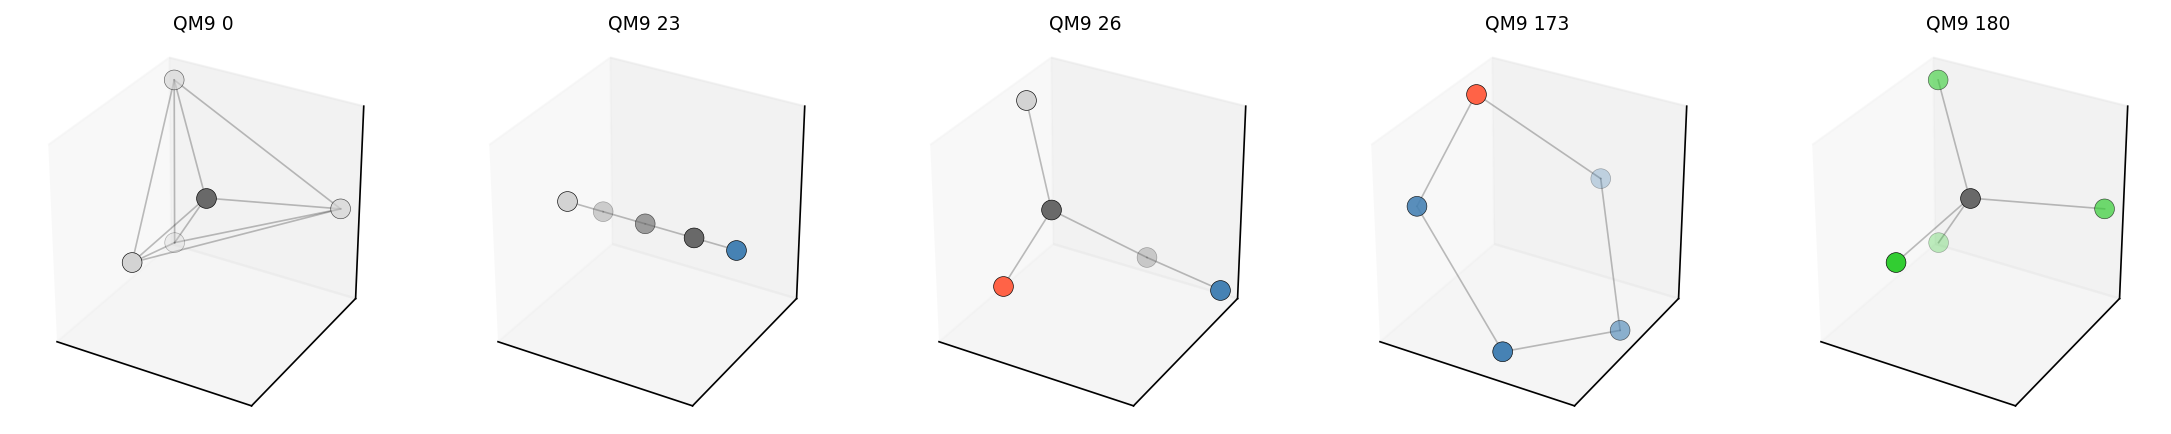

In [32]:
dataset = QM9(str(DATA_ROOT))
real_pos, real_types, real_indices = load_atom_count_cohort(dataset, ATOM_COUNT, MAX_REAL_MOLS, DEVICE)
print(f"atom_count={ATOM_COUNT}, n_real={len(real_indices)}")
print("dataset indices:", real_indices)

fig = plot_real_cohort(real_pos.cpu(), real_types.cpu(), real_indices, max_mols=min(8, len(real_indices)))
_show_figure(fig)


## Run one temperature pair

Use this first to check that training, metrics, and visual output look sane before launching the full grid.


In [33]:
single_row, single_history, single_artifact = run_single_egnn_temperature(
    atom_count=ATOM_COUNT,
    real_pos=real_pos,
    real_types=real_types,
    real_indices=real_indices,
    posit_sigma=POSIT_SIGMA,
    types_sigma=TYPES_SIGMA,
    seed=0,
    n_gen=N_GEN,
    n_eval=N_EVAL,
    num_iters=NUM_ITERS,
    lr=LR,
    posit_eta=POSIT_ETA,
    types_eta=TYPES_ETA,
    scale_loss=SCALE_LOSS,
    device=DEVICE,
    hidden_nf=HIDDEN_NF,
    num_blocks=NUM_BLOCKS,
    num_layers_per_block=NUM_LAYERS_PER_BLOCK,
    attention=ATTENTION,
    tanh_coord_updates=TANH_COORD_UPDATES,
    coords_range=COORDS_RANGE,
    aggr_type=AGGR_TYPE,
    grad_clip=GRAD_CLIP,
    align_max_iter=ALIGN_MAX_ITER,
    log_every=LOG_EVERY,
    save_dir=RESULTS_DIR / "single_runs",
)

single_row


step=    1 loss=14.02 pos=0.002078 type=14.02 grad=14.35
step=  100 loss=3.555 pos=0.001338 type=3.554 grad=0.3122
step=  200 loss=3.556 pos=0.001513 type=3.554 grad=0.3935
step=  300 loss=3.556 pos=0.001632 type=3.554 grad=0.1261
step=  400 loss=3.556 pos=0.001611 type=3.554 grad=0.09885
step=  500 loss=3.556 pos=0.001626 type=3.554 grad=0.2877
step=  600 loss=3.556 pos=0.001602 type=3.554 grad=0.2421
step=  700 loss=3.556 pos=0.001572 type=3.554 grad=0.1043
step=  800 loss=3.556 pos=0.001527 type=3.554 grad=0.7922
step=  900 loss=3.556 pos=0.001586 type=3.554 grad=0.3092
step= 1000 loss=3.556 pos=0.001691 type=3.554 grad=0.1547


{'atom_count': 5,
 'n_real': 5,
 'posit_sigma': 4.0,
 'types_sigma': 0.5,
 'seed': 0,
 'final_loss': 3.5558130741119385,
 'final_position_dist': 0.0016911980928853154,
 'final_type_dist': 3.554121971130371,
 'validity': 0.53515625,
 'uniqueness': 0.014598540145985401,
 'heavy_atom_mean': 5.0,
 'atom_stability': 0.30546875,
 'mol_stability': 0.0,
 'best_match_score': 1.3511652946472168,
 'best_match_pos_rmse': 0.6487283110618591,
 'best_match_type_rmse': 0.7024369239807129,
 'best_match_real_dataset_index': 180,
 'drift_pos_norm': 0.016747185960412025,
 'drift_type_norm': 0.8807448744773865,
 'pos_kernel_entropy': 1.603285789489746,
 'type_kernel_entropy': 1.9514320115376904e-07,
 'pos_effective_neighbors': 4.969378471374512,
 'type_effective_neighbors': 1.000000238418579,
 'grad_norm': 0.15466901659965515,
 'runtime_sec': 376.2202751636505,
 'n_gen': 32,
 'n_eval': 256,
 'num_iters': 1000,
 'lr': 0.0001,
 'posit_eta': 0.5,
 'types_eta': 0.7,
 'scale_loss': 1.0,
 'hidden_nf': 256,
 'num

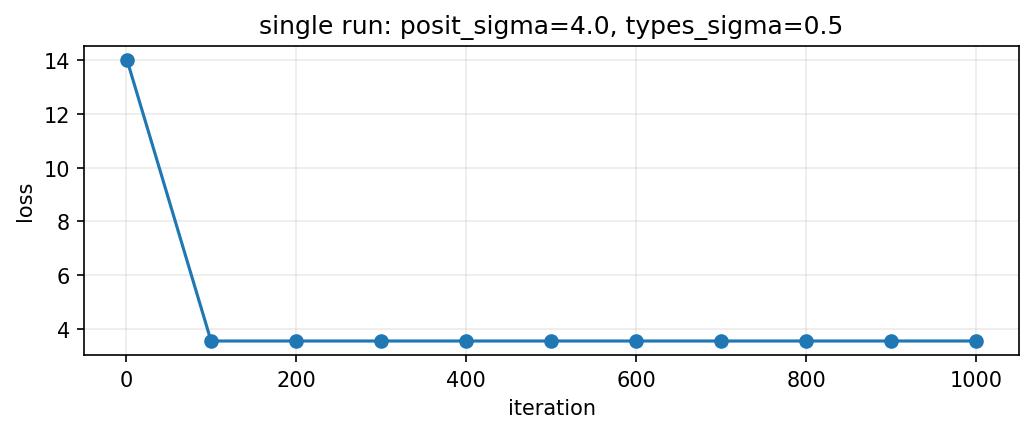

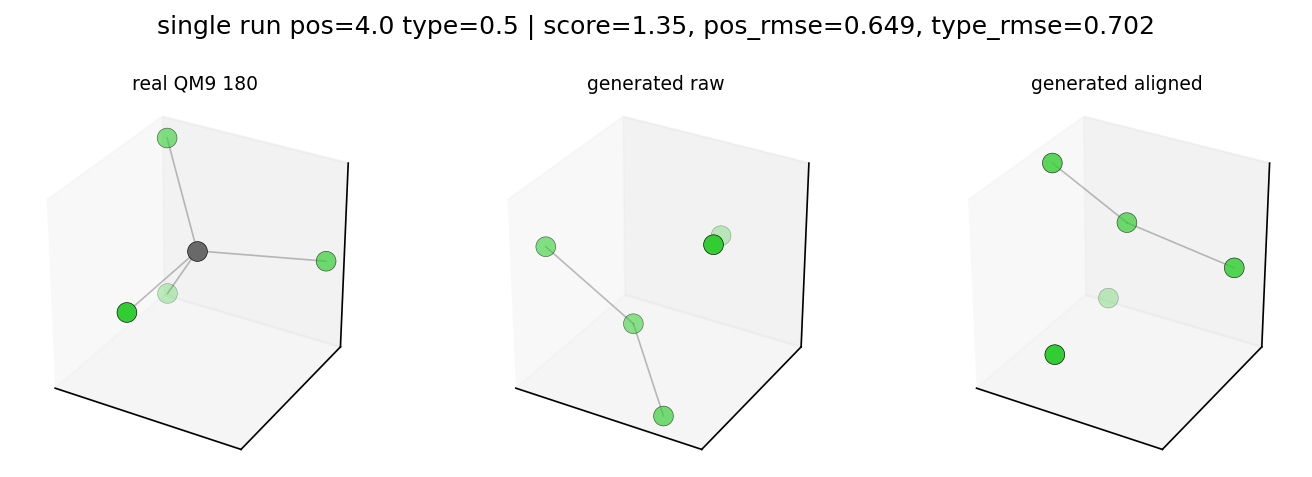

In [34]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot([h["step"] for h in single_history], [h["loss"] for h in single_history], marker="o")
ax.set_xlabel("iteration")
ax.set_ylabel("loss")
ax.set_title(f"single run: posit_sigma={POSIT_SIGMA}, types_sigma={TYPES_SIGMA}")
ax.grid(True, alpha=0.25)
_show_figure(fig)

fig = plot_best_match(single_artifact, title=f"single run pos={POSIT_SIGMA} type={TYPES_SIGMA}")
_show_figure(fig)


## Run a split-temperature grid

This explores high position temperatures against lower atom-type temperatures. Start with `NUM_ITERS=500-1000`, then rerun promising pairs longer.


In [35]:
grid_rows, grid_histories, grid_artifacts = run_temperature_pair_grid(
    atom_count=ATOM_COUNT,
    real_pos=real_pos,
    real_types=real_types,
    real_indices=real_indices,
    posit_sigmas=POSIT_SIGMAS,
    types_sigmas=TYPES_SIGMAS,
    seeds=SEEDS,
    n_gen=N_GEN,
    n_eval=N_EVAL,
    num_iters=NUM_ITERS,
    lr=LR,
    posit_eta=POSIT_ETA,
    types_eta=TYPES_ETA,
    scale_loss=SCALE_LOSS,
    device=DEVICE,
    hidden_nf=HIDDEN_NF,
    num_blocks=NUM_BLOCKS,
    num_layers_per_block=NUM_LAYERS_PER_BLOCK,
    attention=ATTENTION,
    tanh_coord_updates=TANH_COORD_UPDATES,
    coords_range=COORDS_RANGE,
    aggr_type=AGGR_TYPE,
    grad_clip=GRAD_CLIP,
    align_max_iter=ALIGN_MAX_ITER,
    log_every=LOG_EVERY,
    save_dir=RESULTS_DIR / "grid_runs",
)

csv_path = RESULTS_DIR / f"atoms{ATOM_COUNT}_grid_results.csv"
write_results_csv(grid_rows, csv_path)
print(csv_path)
display(best_temperature_pairs(grid_rows, top_k=8))



[atoms=5] posit_sigma=3.0 types_sigma=0.25 seed=0
step=    1 loss=9.413 pos=0.006515 type=9.407 grad=14.66
step=  100 loss=4.248 pos=0.006407 type=4.242 grad=3.804
step=  200 loss=2.454 pos=0.004879 type=2.449 grad=12.42
step=  300 loss=2.454 pos=0.004833 type=2.449 grad=7.053
step=  400 loss=2.454 pos=0.00424 type=2.449 grad=9.744
step=  500 loss=2.454 pos=0.004429 type=2.449 grad=1.51
step=  600 loss=2.455 pos=0.005286 type=2.449 grad=3.403
step=  700 loss=2.454 pos=0.004114 type=2.449 grad=3.208
step=  800 loss=2.454 pos=0.005009 type=2.449 grad=8.915
step=  900 loss=2.454 pos=0.004874 type=2.449 grad=16.97
step= 1000 loss=2.455 pos=0.005025 type=2.449 grad=31.64

[atoms=5] posit_sigma=3.0 types_sigma=0.5 seed=0
step=    1 loss=14.29 pos=0.006377 type=14.28 grad=14.59
step=  100 loss=3.558 pos=0.004334 type=3.554 grad=2.006
step=  200 loss=3.559 pos=0.004708 type=3.554 grad=0.3507
step=  300 loss=3.559 pos=0.005272 type=3.554 grad=0.2002
step=  400 loss=3.559 pos=0.004589 type=3.55

_LinAlgError: linalg.svd: (Batch element 132): The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated singular values (error code: 2).

In [ ]:
for metric in [
    "final_loss",
    "validity",
    "uniqueness",
    "atom_stability",
    "mol_stability",
    "best_match_score",
    "best_match_pos_rmse",
    "best_match_type_rmse",
]:
    fig, _ = plot_temperature_heatmap(grid_rows, metric, title=metric)
    _show_figure(fig)

fig, _ = plot_loss_curves(grid_histories, POSIT_SIGMAS, TYPES_SIGMAS, seed=SEEDS[0])
_show_figure(fig)


In [ ]:
plot_best_matches_for_top_rows(grid_rows, grid_artifacts, top_k=3)


## Loading saved runs without rerunning


In [ ]:
def load_saved_runs(run_dir: str | Path):
    rows, histories, artifacts = [], {}, {}
    for path in sorted(Path(run_dir).glob("*.pt")):
        obj = torch.load(path, map_location="cpu", weights_only=False)
        row = obj["row"]
        key = (float(row["posit_sigma"]), float(row["types_sigma"]), int(row["seed"]))
        rows.append(row)
        histories[key] = obj["history"]
        artifacts[key] = obj["artifact"]
    return rows, histories, artifacts

# Example:
# saved_rows, saved_histories, saved_artifacts = load_saved_runs(RESULTS_DIR / "grid_runs")
# display(best_temperature_pairs(saved_rows))
# plot_best_matches_for_top_rows(saved_rows, saved_artifacts, top_k=3)


## Aligned-loss-style dynamic atom-count runner

This section mirrors the EGNN training cell from `aligned_loss.ipynb` more directly:

- fixed EGNN model per run
- fixed dense edge index for `NUM_GEN` generated molecules
- noise bank sampled by index each iteration
- explicit training loop with gradient logging
- dynamic temperature plan per atom count

Edit `TEMPERATURE_PLAN` to tell the notebook which atom counts to train on and which position/type temperatures to try for each atom count.


In [ ]:
NOISE_BANK_SIZE = 2048

TEMPERATURE_PLAN = {
    5: {
        "posit_sigmas": [3.0, 4.0, 5.0, 6.0],
        "types_sigmas": [0.25, 0.5, 1.0, 2.0],
        "seeds": [0],
        "num_gen": 20,
        "num_iters": 1000,
        "n_eval": 256,
    },
    # Example: uncomment to run the same style for all 6-atom molecules.
    # 6: {
    #     "posit_sigmas": [3.0, 4.0, 5.0, 6.0],
    #     "types_sigmas": [0.25, 0.5, 1.0, 2.0],
    #     "seeds": [0],
    #     "num_gen": 20,
    #     "num_iters": 1000,
    #     "n_eval": 256,
    # },
}

DEFAULT_ALIGNED_STYLE_CFG = dict(
    lr=LR,
    posit_eta=POSIT_ETA,
    types_eta=TYPES_ETA,
    scale_loss=SCALE_LOSS,
    hidden_nf=HIDDEN_NF,
    num_blocks=NUM_BLOCKS,
    num_layers_per_block=NUM_LAYERS_PER_BLOCK,
    attention=ATTENTION,
    tanh_coord_updates=TANH_COORD_UPDATES,
    coords_range=COORDS_RANGE,
    aggr_type=AGGR_TYPE,
    grad_clip=GRAD_CLIP,
    align_max_iter=ALIGN_MAX_ITER,
    log_every=1000,
    noise_bank_size=NOISE_BANK_SIZE,
)


In [ ]:
def make_noise_bank(noise_bank_size: int, num_atoms: int, device: torch.device):
    pos_noise_bank = torch.randn((noise_bank_size, num_atoms, 3), device=device)
    pos_noise_bank = center_positions(pos_noise_bank)
    type_noise_bank = torch.randn((noise_bank_size, num_atoms, NUM_ATOM_TYPES), device=device)
    return pos_noise_bank, type_noise_bank


def forward_egnn_from_noise(
    model: EGNN,
    pos_noise: torch.Tensor,
    type_noise: torch.Tensor,
    dense_edge_index: torch.Tensor,
    num_gen: int,
    num_atoms: int,
):
    gen_pos, gen_types = model(
        pos_noise.reshape(num_gen * num_atoms, 3),
        type_noise.reshape(num_gen * num_atoms, NUM_ATOM_TYPES),
        dense_edge_index,
    )
    gen_pos = center_positions(gen_pos.reshape(num_gen, num_atoms, 3))
    gen_types = gen_types.reshape(num_gen, num_atoms, NUM_ATOM_TYPES)
    gen_types_prob = F.softmax(gen_types, dim=-1)
    gen_types_sphere = probs_to_sphere(gen_types_prob, eps=1e-8)
    return gen_pos, gen_types_prob, gen_types_sphere


def run_single_aligned_loss_style_egnn(
    *,
    atom_count: int,
    real_pos: torch.Tensor,
    real_types: torch.Tensor,
    real_indices: list[int],
    posit_sigma: float,
    types_sigma: float,
    seed: int,
    num_gen: int,
    num_iters: int,
    n_eval: int,
    device: torch.device | str,
    lr: float,
    posit_eta: float,
    types_eta: float,
    scale_loss: float,
    hidden_nf: int,
    num_blocks: int,
    num_layers_per_block: int,
    attention: bool,
    tanh_coord_updates: bool,
    coords_range: float,
    aggr_type: str,
    grad_clip: float | None,
    align_max_iter: int,
    log_every: int,
    noise_bank_size: int,
    save_dir: str | Path | None = None,
):
    device = torch.device(device)
    set_seed(seed)
    real_pos = real_pos.to(device)
    real_types = real_types.to(device)

    model = EGNN(
        num_atom_types=NUM_ATOM_TYPES,
        num_blocks=num_blocks,
        hidden_nf=hidden_nf,
        num_layers_per_block=num_layers_per_block,
        attention=attention,
        tanh_coord_updates=tanh_coord_updates,
        coords_range=coords_range,
        aggr_type=aggr_type,
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    dense_edge_index = make_batched_dense_edge_index(num_gen, atom_count, device)
    pos_noise_bank, type_noise_bank = make_noise_bank(noise_bank_size, atom_count, device)

    loss_list = []
    history = []
    last_loss = math.nan
    last_stats = {}
    last_grad_norm = math.nan
    last_mean_abs_grad = math.nan
    start_time = time.time()

    for iteration in range(num_iters):
        optimizer.zero_grad(set_to_none=True)
        idx = torch.randint(0, noise_bank_size, (num_gen,), device=device)
        pos_noise = pos_noise_bank[idx]
        type_noise = type_noise_bank[idx]

        gen_pos, gen_types_prob, gen_types_sphere = forward_egnn_from_noise(
            model,
            pos_noise,
            type_noise,
            dense_edge_index,
            num_gen,
            atom_count,
        )

        loss, stats = compute_aligning_drift_loss(
            gen_pos,
            real_pos,
            gen_types_sphere,
            real_types,
            posit_sigma=posit_sigma,
            types_sigma=types_sigma,
            posit_eta=posit_eta,
            types_eta=types_eta,
            scale_loss=scale_loss,
            align_max_iter=align_max_iter,
        )
        loss.backward()

        grads = [p.grad.detach().flatten() for p in model.parameters() if p.grad is not None]
        if grads:
            all_grads = torch.cat(grads)
            last_mean_abs_grad = float(all_grads.abs().mean().cpu().item())
        else:
            last_mean_abs_grad = math.nan

        if grad_clip is not None:
            last_grad_norm = float(torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip).detach().cpu().item())
        optimizer.step()

        last_loss = float(loss.detach().cpu().item())
        last_stats = stats
        loss_list.append(last_loss)

        if iteration == 0 or (iteration + 1) % log_every == 0 or iteration + 1 == num_iters:
            item = {
                "step": iteration + 1,
                "loss": last_loss,
                "mean_abs_grad": last_mean_abs_grad,
                "total_grad_norm": last_grad_norm,
                "position_dist": float(stats["position_dist"].cpu().item()),
                "type_dist": float(stats["type_dist"].cpu().item()),
                "drift_pos_norm": float(stats["drift_pos_norm"].cpu().item()),
                "drift_type_norm": float(stats["drift_type_norm"].cpu().item()),
                "pos_kernel_entropy": float(stats["pos_kernel_entropy"].cpu().item()),
                "type_kernel_entropy": float(stats["type_kernel_entropy"].cpu().item()),
                "pos_effective_neighbors": float(stats["pos_effective_neighbors"].cpu().item()),
                "type_effective_neighbors": float(stats["type_effective_neighbors"].cpu().item()),
            }
            history.append(item)
            print(f"Iter {iteration}: Loss = {last_loss}")
            print(
                f"mean_abs_grad={last_mean_abs_grad:.6f}, "
                f"total_grad_norm={last_grad_norm:.6f}, "
                f"position_dist={item['position_dist']:.6f}, "
                f"type_dist={item['type_dist']:.6f}, "
                f"drift_pos_norm={item['drift_pos_norm']:.6f}, "
                f"drift_type_norm={item['drift_type_norm']:.6f}, "
                f"pos_effective_neighbors={item['pos_effective_neighbors']:.6f}, "
                f"type_effective_neighbors={item['type_effective_neighbors']:.6f}"
            )

    runtime_sec = time.time() - start_time
    with torch.no_grad():
        eval_pos, eval_probs, _ = generate_egnn_samples(model, n_eval, atom_count, device)

    chem = evaluate_generated_molecules(eval_pos, eval_probs)
    best_match = select_best_generated_match(
        eval_pos,
        eval_probs,
        real_pos,
        real_types,
        align_max_iter=align_max_iter,
    )
    best_match["real_dataset_index"] = int(real_indices[best_match["real_local_index"]])

    row = {
        "atom_count": int(atom_count),
        "n_real": int(real_pos.shape[0]),
        "posit_sigma": float(posit_sigma),
        "types_sigma": float(types_sigma),
        "seed": int(seed),
        "final_loss": float(last_loss),
        "final_position_dist": float(last_stats["position_dist"].cpu().item()),
        "final_type_dist": float(last_stats["type_dist"].cpu().item()),
        "validity": chem["validity"],
        "uniqueness": chem["uniqueness"],
        "heavy_atom_mean": chem["heavy_atom_mean"],
        "atom_stability": chem["atom_stability"],
        "mol_stability": chem["mol_stability"],
        "best_match_score": best_match["score"],
        "best_match_pos_rmse": best_match["pos_rmse"],
        "best_match_type_rmse": best_match["type_rmse"],
        "best_match_real_dataset_index": best_match["real_dataset_index"],
        "mean_abs_grad": float(last_mean_abs_grad),
        "grad_norm": float(last_grad_norm),
        "runtime_sec": float(runtime_sec),
        "num_gen": int(num_gen),
        "n_eval": int(n_eval),
        "num_iters": int(num_iters),
        "lr": float(lr),
        "posit_eta": float(posit_eta),
        "types_eta": float(types_eta),
        "scale_loss": float(scale_loss),
        "noise_bank_size": int(noise_bank_size),
        "hidden_nf": int(hidden_nf),
        "num_blocks": int(num_blocks),
        "num_layers_per_block": int(num_layers_per_block),
    }

    artifact = {
        "loss_list": loss_list,
        "gen_pos": eval_pos[: min(12, n_eval)].detach().cpu(),
        "gen_type_probs": eval_probs[: min(12, n_eval)].detach().cpu(),
        "real_pos": real_pos.detach().cpu(),
        "real_types": real_types.detach().cpu(),
        "real_indices": list(real_indices),
        "best_match": best_match,
    }

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        out_path = save_dir / f"atoms{atom_count}_pos{_float_key(posit_sigma)}_type{_float_key(types_sigma)}_seed{seed}.pt"
        torch.save({"row": row, "history": history, "artifact": artifact}, out_path)
        row["artifact_path"] = str(out_path)

    return row, history, artifact


In [ ]:
def run_aligned_loss_style_temperature_plan(
    *,
    dataset: QM9,
    plan: dict[int, dict[str, Any]],
    device: torch.device | str,
    max_real_mols: int | None = None,
    save_dir: str | Path | None = None,
    default_cfg: dict[str, Any] | None = None,
):
    default_cfg = dict(DEFAULT_ALIGNED_STYLE_CFG if default_cfg is None else default_cfg)
    rows, histories, artifacts = [], {}, {}

    for atom_count, atom_plan in plan.items():
        real_pos, real_types, real_indices = load_atom_count_cohort(
            dataset,
            atom_count,
            max_mols=atom_plan.get("max_real_mols", max_real_mols),
            device=device,
        )
        print(f"\n=== atom_count={atom_count}, n_real={len(real_indices)} ===")

        run_cfg = dict(default_cfg)
        for key in [
            "lr",
            "posit_eta",
            "types_eta",
            "scale_loss",
            "hidden_nf",
            "num_blocks",
            "num_layers_per_block",
            "attention",
            "tanh_coord_updates",
            "coords_range",
            "aggr_type",
            "grad_clip",
            "align_max_iter",
            "log_every",
            "noise_bank_size",
        ]:
            if key in atom_plan:
                run_cfg[key] = atom_plan[key]

        for posit_sigma in atom_plan["posit_sigmas"]:
            for types_sigma in atom_plan["types_sigmas"]:
                for seed in atom_plan.get("seeds", [0]):
                    print(
                        f"\n[atoms={atom_count}] posit_sigma={posit_sigma} "
                        f"types_sigma={types_sigma} seed={seed}"
                    )
                    row, history, artifact = run_single_aligned_loss_style_egnn(
                        atom_count=atom_count,
                        real_pos=real_pos,
                        real_types=real_types,
                        real_indices=real_indices,
                        posit_sigma=posit_sigma,
                        types_sigma=types_sigma,
                        seed=seed,
                        num_gen=atom_plan.get("num_gen", N_GEN),
                        num_iters=atom_plan.get("num_iters", NUM_ITERS),
                        n_eval=atom_plan.get("n_eval", N_EVAL),
                        device=device,
                        save_dir=save_dir,
                        **run_cfg,
                    )
                    key = (int(atom_count), float(posit_sigma), float(types_sigma), int(seed))
                    rows.append(row)
                    histories[key] = history
                    artifacts[key] = artifact
    return rows, histories, artifacts


def rows_for_atom_count(rows: list[dict[str, Any]], atom_count: int) -> list[dict[str, Any]]:
    return [row for row in rows if int(row["atom_count"]) == int(atom_count)]


def best_temperature_pairs_for_atom_count(rows: list[dict[str, Any]], atom_count: int, top_k: int = 8):
    return best_temperature_pairs(rows_for_atom_count(rows, atom_count), top_k=top_k)


def plot_best_matches_for_plan_rows(rows, artifacts, atom_count: int, top_k: int = 3):
    top = best_temperature_pairs_for_atom_count(rows, atom_count, top_k=top_k)
    for row in top:
        key = (int(atom_count), row["posit_sigma"], row["types_sigma"], row["seed"])
        artifact = artifacts.get(key)
        if artifact is None:
            continue
        fig = plot_best_match(artifact, title=f"atoms={atom_count} pos={row['posit_sigma']} type={row['types_sigma']}")
        _show_figure(fig)


In [ ]:
# Run the dynamic plan. This is the cell you edit/run when you want aligned_loss-style sweeps.
# Start with small num_iters in TEMPERATURE_PLAN, then increase promising settings.

plan_rows, plan_histories, plan_artifacts = run_aligned_loss_style_temperature_plan(
    dataset=dataset,
    plan=TEMPERATURE_PLAN,
    device=DEVICE,
    max_real_mols=MAX_REAL_MOLS,
    save_dir=RESULTS_DIR / "aligned_loss_style_runs",
)

plan_csv_path = RESULTS_DIR / "aligned_loss_style_plan_results.csv"
write_results_csv(plan_rows, plan_csv_path)
print(plan_csv_path)

for atom_count in TEMPERATURE_PLAN:
    print(f"best pairs for atom_count={atom_count}")
    display(best_temperature_pairs_for_atom_count(plan_rows, atom_count, top_k=8))


In [ ]:
for atom_count in TEMPERATURE_PLAN:
    atom_rows = rows_for_atom_count(plan_rows, atom_count)
    for metric in ["final_loss", "validity", "mol_stability", "atom_stability", "best_match_score"]:
        fig, _ = plot_temperature_heatmap(atom_rows, metric, title=f"atoms={atom_count}: {metric}")
        _show_figure(fig)

    posit_sigmas = TEMPERATURE_PLAN[atom_count]["posit_sigmas"]
    types_sigmas = TEMPERATURE_PLAN[atom_count]["types_sigmas"]
    seed = TEMPERATURE_PLAN[atom_count].get("seeds", [0])[0]
    atom_histories = {
        (pos, typ, s): hist
        for (atoms, pos, typ, s), hist in plan_histories.items()
        if atoms == atom_count
    }
    fig, _ = plot_loss_curves(atom_histories, posit_sigmas, types_sigmas, seed=seed)
    _show_figure(fig)

    plot_best_matches_for_plan_rows(plan_rows, plan_artifacts, atom_count, top_k=3)
